In [0]:
# Week 2.2 — Customer Segmentation (K-Means)


In [0]:
#Config + load data
CATALOG = "cx"
SCHEMA_GOLD = "cx_gold"

import pandas as pd
import numpy as np

# Pull customer_360 to pandas (50K rows is fine in memory)
customer_360_sdf = spark.table(f"{CATALOG}.{SCHEMA_GOLD}.customer_360")
df = customer_360_sdf.toPandas()
print(f"Loaded {len(df):,} customers")
df.head(3)

Loaded 50,000 customers


,customer_id,customer_name,customer_type,region,country,service_tier,contract_start_date,annual_recurring_revenue_usd,employee_count,primary_contact_email,ingestion_timestamp,source_file,dq_flag_missing_email,dq_flag_missing_type,total_tickets,critical_tickets,escalated_tickets,avg_first_response_min,avg_resolution_hours,avg_post_ticket_csat,last_ticket_date,avg_monthly_test_volume,avg_uptime_pct,avg_monthly_errors,active_instruments,software_versions_used,latest_nps,latest_nps_bucket,latest_csat,latest_ces,latest_survey_date,total_survey_responses,avg_nps_lifetime,tenure_days,tenure_years,tickets_per_year,has_recent_critical,engagement_score
0,CUST_000018,Account_18,Clinical Lab,APAC,Japan,Bronze,2023-10-02,79579.06,10000,contact_18@example.com,2026-05-19 19:49:49.910187,customers.csv,0,0,4,0,0,40.5,48.12,4.00,2024-12-17 18:00:00,4603.0,0.9832,2.50,2,4.0,NaN,None,NaN,NaN,None,0,NaN,962,2.63,1.52,0,0.67
1,CUST_000036,Account_36,Research,North America,USA,Bronze,2019-05-20,291061.21,1000,contact_36@example.com,2026-05-19 19:49:49.910187,customers.csv,0,0,6,0,0,27.3,60.68,3.83,2025-03-11 11:00:00,5526.0,0.8929,2.42,5,3.0,NaN,None,NaN,NaN,None,0,NaN,2558,7.00,0.86,0,0.67
2,CUST_000066,Account_66,Clinical Lab,North America,USA,Bronze,2020-10-28,17366.40,1000,contact_66@example.com,2026-05-19 19:49:49.910187,customers.csv,0,0,1,0,0,38.3,0.92,NaN,2025-01-29 08:00:00,901.0,0.8903,2.75,1,3.0,NaN,None,NaN,NaN,None,0,NaN,2031,5.56,0.18,0,0.33


In [0]:
#Feature selection

In [0]:
feature_cols = [
    "annual_recurring_revenue_usd",   # value
    "tenure_years",                    # maturity
    "total_tickets",                   # support burden
    "tickets_per_year",                # normalized support burden
    "escalated_tickets",               # severity of issues
    "avg_first_response_min",          # service quality received
    "avg_monthly_test_volume",         # usage intensity
    "avg_uptime_pct",                  # product reliability experience
    "avg_monthly_errors",              # product trouble
    "active_instruments",              # account size
    "total_survey_responses",          # engagement with VoC
    "engagement_score",                # composite engagement
]

X = df[feature_cols].copy()
print(f"Feature matrix shape: {X.shape}")
print(f"\nMissing values per feature:")
print(X.isnull().sum())


Feature matrix shape: (50000, 12)

Missing values per feature:
annual_recurring_revenue_usd        0
tenure_years                        0
total_tickets                       0
tickets_per_year                 1329
escalated_tickets                   0
avg_first_response_min           1329
avg_monthly_test_volume         10000
avg_uptime_pct                  10000
avg_monthly_errors              10000
active_instruments                  0
total_survey_responses              0
engagement_score                    0
dtype: int64


In [0]:
## Handle missing values

##K-means can't handle NaN. Strategy:
##- **Usage features** missing → customer has no telemetry → impute with 0
##- **Survey features** missing → already filled with 0 in Gold
##- **First response min** missing → no tickets → impute with median (neutral) 

In [0]:
X["avg_monthly_test_volume"] = X["avg_monthly_test_volume"].fillna(0)
X["avg_uptime_pct"] = X["avg_uptime_pct"].fillna(X["avg_uptime_pct"].median())
X["avg_monthly_errors"] = X["avg_monthly_errors"].fillna(0)
X["avg_first_response_min"] = X["avg_first_response_min"].fillna(X["avg_first_response_min"].median())
X["tickets_per_year"] = X["tickets_per_year"].fillna(0)

assert X.isnull().sum().sum() == 0, "Still have nulls!"
print("✅ All features imputed")

✅ All features imputed


In [0]:
##Scale features
#ARR is in dollars (10K–500K), uptime is 0–1, ticket counts are 0–50.
#K-means would weight ARR ~10,000x more than uptime without scaling

In [0]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled feature matrix: mean ≈ 0, std ≈ 1")
print(f"Sample means: {X_scaled.mean(axis=0)[:3].round(3)}")
print(f"Sample stds:  {X_scaled.std(axis=0)[:3].round(3)}")


Scaled feature matrix: mean ≈ 0, std ≈ 1
Sample means: [-0.  0. -0.]
Sample stds:  [1. 1. 1.]


In [0]:
# Choose K (elbow method)

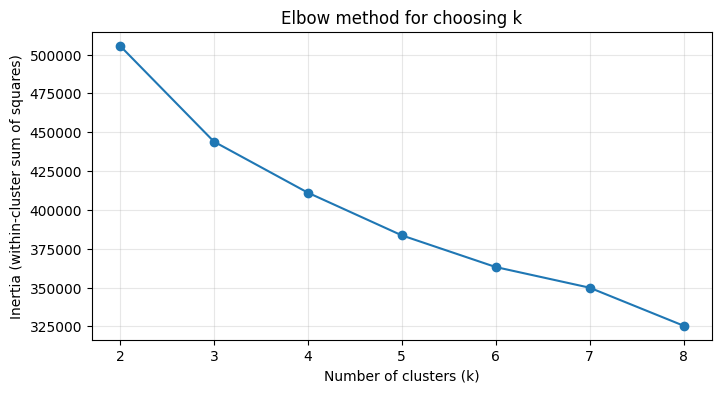

In [0]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow method for choosing k")
plt.grid(True, alpha=0.3)
plt.show()

In [0]:
#The elbow typically appears at k=4 or k=5. We'll use **k=4** — interpretable for business stakeholders.


In [0]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

df["segment_id"] = clusters
print(f"✅ Assigned {K} segments")
print(f"\nSegment sizes:")
print(df["segment_id"].value_counts().sort_index())

✅ Assigned 4 segments

Segment sizes:
segment_id
0     8613
1    23110
2     9544
3     8733
Name: count, dtype: int64


In [0]:
## Profile each segment
#Compute the mean of each feature per segment to understand who's in each cluster.


In [0]:
profile = df.groupby("segment_id")[feature_cols].mean().round(2)
profile["customer_count"] = df["segment_id"].value_counts().sort_index()
profile = profile[["customer_count"] + feature_cols]
profile.T  # transpose for readability

segment_id,0,1,2,3
customer_count,8613.00,23110.00,9544.00,8733.00
annual_recurring_revenue_usd,66125.54,67042.25,64527.36,65686.41
tenure_years,4.34,5.03,4.96,4.99
total_tickets,14.08,5.07,6.45,5.69
tickets_per_year,3.47,1.10,1.45,1.25
escalated_tickets,2.08,0.50,0.74,0.61
avg_first_response_min,65.43,65.49,65.63,64.72
avg_monthly_test_volume,2040.41,2077.02,380.92,2376.60
avg_uptime_pct,0.93,0.94,0.95,0.94
avg_monthly_errors,2.99,3.01,1.56,3.00


In [0]:
#Auto-name segments

In [0]:
def name_segment(row):
    """Heuristic naming based on relative feature levels."""
    arr_rank = (profile["annual_recurring_revenue_usd"] >= row["annual_recurring_revenue_usd"]).sum()
    tickets = row["tickets_per_year"]
    engagement = row["engagement_score"]

    if arr_rank == 1 and tickets < profile["tickets_per_year"].median():
        return "Strategic Champions"
    elif tickets > profile["tickets_per_year"].quantile(0.75):
        return "At-Risk High-Touch"
    elif engagement < profile["engagement_score"].median() and tickets < profile["tickets_per_year"].median():
        return "Dormant / Low-Engagement"
    else:
        return "Steady-State Operators"

profile["segment_name"] = profile.apply(name_segment, axis=1)
print(profile[["customer_count", "annual_recurring_revenue_usd", "tickets_per_year",
               "avg_uptime_pct", "engagement_score", "segment_name"]])

# Map names to customer-level dataframe
segment_name_map = profile["segment_name"].to_dict()
df["segment_name"] = df["segment_id"].map(segment_name_map)

            customer_count  ...            segment_name
segment_id                  ...                        
0                     8613  ...      At-Risk High-Touch
1                    23110  ...     Strategic Champions
2                     9544  ...  Steady-State Operators
3                     8733  ...  Steady-State Operators

[4 rows x 6 columns]


In [0]:
# Save back to Gold

In [0]:
segments_out = df[["customer_id", "segment_id", "segment_name"]].copy()
spark.createDataFrame(segments_out).write.mode("overwrite").format("delta").saveAsTable(
    f"{CATALOG}.{SCHEMA_GOLD}.customer_segments"
)
print(f"✅ Saved {len(segments_out):,} rows to {CATALOG}.{SCHEMA_GOLD}.customer_segments")

profile_out = profile.reset_index()
spark.createDataFrame(profile_out).write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable(
    f"{CATALOG}.{SCHEMA_GOLD}.segment_profiles"
)
print(f"✅ Saved segment profiles to {CATALOG}.{SCHEMA_GOLD}.segment_profiles")

✅ Saved 50,000 rows to cx.cx_gold.customer_segments
✅ Saved segment profiles to cx.cx_gold.segment_profiles


In [0]:
#Segment distribution

In [0]:
%sql
SELECT segment_name, COUNT(*) AS customers
FROM cx.cx_gold.customer_segments
GROUP BY segment_name
ORDER BY customers DESC

segment_name,customers
Strategic Champions,23110
Steady-State Operators,18277
At-Risk High-Touch,8613


In [0]:
#NPS bucket by segment (insight territory)

In [0]:

%sql
SELECT s.segment_name, c.latest_nps_bucket, COUNT(*) AS n
FROM cx.cx_gold.customer_segments s
JOIN cx.cx_gold.customer_360 c USING (customer_id)
WHERE c.latest_nps_bucket IS NOT NULL
GROUP BY s.segment_name, c.latest_nps_bucket
ORDER BY s.segment_name, c.latest_nps_bucket

segment_name,latest_nps_bucket,n
At-Risk High-Touch,Detractor,771
At-Risk High-Touch,Passive,589
At-Risk High-Touch,Promoter,690
Steady-State Operators,Detractor,4316
Steady-State Operators,Passive,3442
Steady-State Operators,Promoter,3792
Strategic Champions,Detractor,483
Strategic Champions,Passive,419
Strategic Champions,Promoter,456


In [0]:
%sql
SELECT segment_id, segment_name, COUNT(*) AS customers
FROM cx.cx_gold.customer_segments
GROUP BY segment_id, segment_name
ORDER BY segment_id;

segment_id,segment_name,customers
0,At-Risk High-Touch,8613
1,Strategic Champions,23110
2,Steady-State Operators,9544
3,Steady-State Operators,8733


In [0]:
profile = spark.table("cx.cx_gold.segment_profiles").toPandas()
profile.set_index("segment_id").T

segment_id,0,1,2,3
customer_count,8613,23110,9544,8733
annual_recurring_revenue_usd,66125.54,67042.25,64527.36,65686.41
tenure_years,4.34,5.03,4.96,4.99
total_tickets,14.08,5.07,6.45,5.69
tickets_per_year,3.47,1.1,1.45,1.25
escalated_tickets,2.08,0.5,0.74,0.61
avg_first_response_min,65.43,65.49,65.63,64.72
avg_monthly_test_volume,2040.41,2077.02,380.92,2376.6
avg_uptime_pct,0.93,0.94,0.95,0.94
avg_monthly_errors,2.99,3.01,1.56,3.0


In [0]:
manual_name_map = {
    0: "At-Risk High-Touch",
    1: "Silent Majority",
    2: "Dormant / Disengaged",
    3: "Strategic Champions",
}

# Update customer_segments
segs_df = spark.table("cx.cx_gold.customer_segments").toPandas()
segs_df["segment_name"] = segs_df["segment_id"].map(manual_name_map)

spark.createDataFrame(segs_df).write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable(
    "cx.cx_gold.customer_segments"
)
print("Updated customer_segments. New counts:")
print(segs_df["segment_name"].value_counts())

# Also update segment_profiles to stay consistent
profile_df = spark.table("cx.cx_gold.segment_profiles").toPandas()
profile_df["segment_name"] = profile_df["segment_id"].map(manual_name_map)

spark.createDataFrame(profile_df).write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable(
    "cx.cx_gold.segment_profiles"
)
print("\nUpdated segment_profiles too.")

Updated customer_segments. New counts:
segment_name
Silent Majority         23110
Dormant / Disengaged     9544
Strategic Champions      8733
At-Risk High-Touch       8613
Name: count, dtype: int64

Updated segment_profiles too.


In [0]:
%sql
SELECT segment_id, segment_name, COUNT(*) AS customers
FROM cx.cx_gold.customer_segments
GROUP BY segment_id, segment_name
ORDER BY segment_id;

segment_id,segment_name,customers
0,At-Risk High-Touch,8613
1,Silent Majority,23110
2,Dormant / Disengaged,9544
3,Strategic Champions,8733
